In [102]:
import pandas as pd
data = pd.read_csv('data/data.csv',sep= ';')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129972 entries, 0 to 129971
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             129972 non-null  int64  
 1   country                129909 non-null  object 
 2   description            129972 non-null  object 
 3   designation            129972 non-null  object 
 4   points                 129972 non-null  int64  
 5   province               129909 non-null  object 
 6   region_1               129972 non-null  object 
 7   taster_name            129972 non-null  object 
 8   taster_twitter_handle  129972 non-null  object 
 9   title                  129972 non-null  object 
 10  variety                129971 non-null  object 
 11  winery                 129972 non-null  object 
 12  price_round            129972 non-null  int64  
 13  year                   125332 non-null  object 
 14  is_usa                 129972 non-nu

# <center> Кодирование признаков. Методы

>Процесс преобразования категориальных данных в признаки, пригодные для обучения, называется кодированием признаков.

### <center> Схема выбора метода кодирования

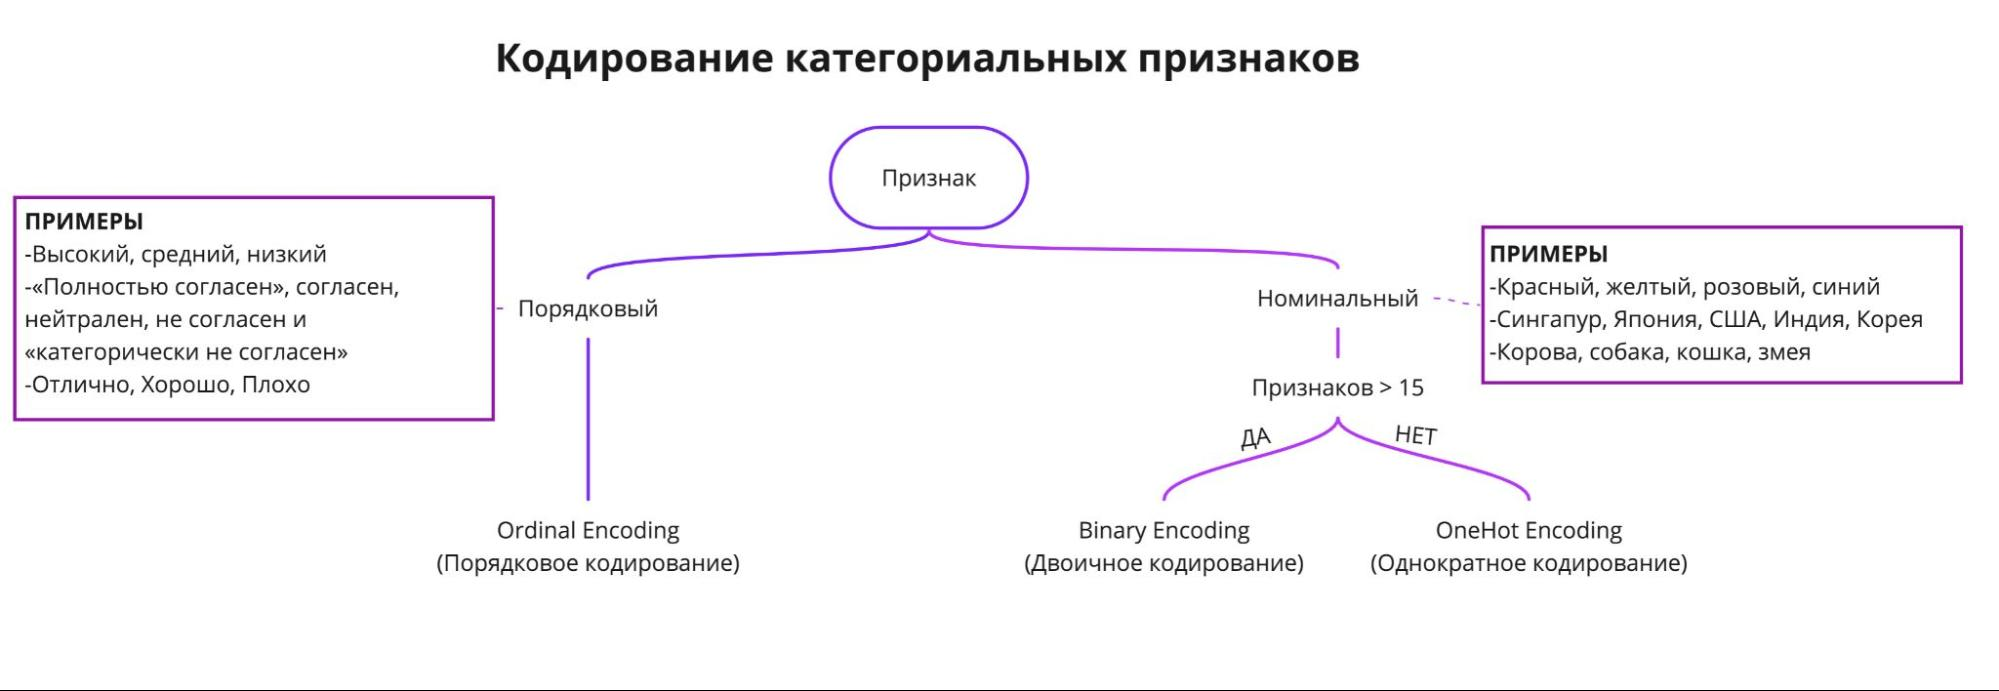

Если признак, который вы собираетесь кодировать, **порядковый**, используйте **порядковое кодирование (Ordinal Encoding)**.

Для номинальных признаков важно количество уникальных значений признака, так как при их большом количестве могут возникать проблемы с памятью. Если у признака меньше 15 значений, следует выбирать для данных **однократное кодирование (OneHot Encoding)**. 

Число 15 выбрано эмпирически — для вашего набора данных это число может быть 20 или 10. Это зависит от количества признаков в вашем датасете, количестве строк и многих других факторов. 

Если признаков немного, то вы также можете воспользоваться **однократным кодированием**. В других ситуациях вам стоит выбрать другой способ кодирования, например **бинарный (Binary Encoding)**.

Ниже мы рассмотрим методы кодирования, обозначенные в блок-схеме. Для кодирования категориальных признаков мы будем использовать библиотеку [category_encoders](https://contrib.scikit-learn.org/category_encoders/). Это удобная библиотека для кодирования категориальных переменных различными методами.

Установим библиотеку:
```python
pip install category_encoders
```
Импортируем библиотеку category-encoders для дальнейшего использования. 

In [103]:
import category_encoders as ce

Рассмотрим следующие популярные способы кодирования: 
* порядковое кодирование (*Ordinal Encoding*); 
* однократное кодирование (*OneHot Encoding*); 
* бинарное кодирование (*Binary Encoding*).

Создадим обучающий набор для кодирования порядковых признаков — ассортимент небольшого магазина с одеждой, где size — буквенное обозначение размера одежды, type — тип изделия.

In [116]:
import pandas as pd
# инициализируем информацию об одежде
clothing_list = [
    ['xxs', 'dress'],
    ['xxs', 'skirt'],
    ['xs', 'dress'],
    ['s', 'skirt'],
    ['m', 'dress'],
    ['l', 'shirt'],
    ['s', 'coat'],
    ['m', 'coat'],
    ['xxl', 'shirt'],
    ['l', 'dress']
]

clothing = pd.DataFrame(clothing_list, columns = ['size',  'type'])
clothing

,size,type
0,xxs,dress
1,xxs,skirt
2,xs,dress
3,s,skirt
4,m,dress
5,l,shirt
6,s,coat
7,m,coat
8,xxl,shirt
9,l,dress


## <center> Порядковое кодирование. Ordinal Encoding

В порядковой кодировке признаков каждому строковому значению присваивается значение в виде целого числа, свойственного для конкретного значения строки.

Результат кодирования порядкового признака size будет выглядеть так: каждому строковому значению присваивается значение в виде целого числа.



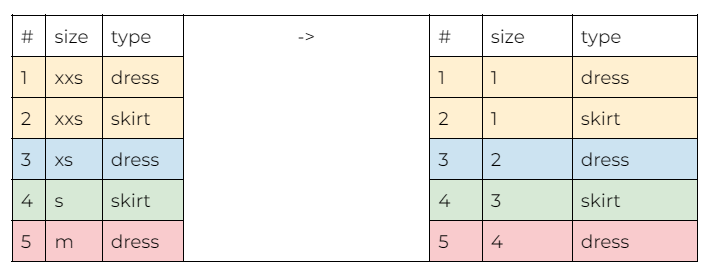

Выполним теперь кодирование порядкового признака size в Python. Порядковое кодирование в библиотеке реализовано в классе [OrdinalEncoder](https://contrib.scikit-learn.org/category_encoders/ordinal.html). По умолчанию все строковые столбцы будут закодированы.

Метод fit_transform устанавливает соответствия для кодирования и преобразовывает данные в соответствие с ними. Затем используем метод [concat()](https://pandas.pydata.org/docs/reference/api/pandas.concat.html) для добавления закодированного признака в датафрейм data.

In [117]:
# импортируем библиотеку для работы с кодировщиками
import category_encoders as ce 

# создаем объект OrdinalEncoder, col - имя столбца, mapping - словарь с описанием кодировки
ord_encoder = ce.OrdinalEncoder(mapping=[{
	'col': 'size',
	'mapping': {'xxs': 1, 'xs': 2, 's': 3, 
                'm': 4, 'l': 5, 'xxl': 6}
}])
# применяем трансформацию к столбцу
data_bin = ord_encoder.fit_transform(clothing[['size']])
# добавляем результат к исходному DataFrame
clothing1 = pd.concat([clothing, data_bin], axis=1)

clothing1

,size,type,size
0,xxs,dress,1
1,xxs,skirt,1
2,xs,dress,2
3,s,skirt,3
4,m,dress,4
5,l,shirt,5
6,s,coat,3
7,m,coat,4
8,xxl,shirt,6
9,l,dress,5


>Однако порядковое кодирование плохо работает для номинальных признаков. Ошибку при кодировании мы не получим, но алгоритмы машинного обучения не могут различать категории и числовые признаки, поэтому могут быть сделаны выводы о неправильном порядке. 

In [106]:
import re
import category_encoders as ce
# Если бы ни было столбца YEAR до этого, с помощью регулярки (ниже) можно было бы вытащить год из title
#regex = '\d{4}'
#data['year'] = data['title'].str.findall(regex).str.get(0)

ord_encoder = ce.OrdinalEncoder()
data_bin = ord_encoder.fit_transform(data['year'])
data = pd.concat([data, data_bin], axis=1)


In [107]:
data.columns = ['Unnamed: 0', 'country', 'description', 'designation', 'points',
       'province', 'region_1', 'taster_name', 'taster_twitter_handle', 'title',
       'variety', 'winery', 'price_round', 'year_from_title', 'is_usa', 'is_france',
       'is_italy', 'old_wine', 'locality', 'population', 'area', 'years_diff',
       'year']

In [108]:
data.head(3)

,Unnamed: 0,country,description,designation,points,province,region_1,taster_name,taster_twitter_handle,title,...,year_from_title,is_usa,is_france,is_italy,old_wine,locality,population,area,years_diff,year
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,Sicily & Sardinia,Etna,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),...,2013-01-01,0,0,1,0,Etna,"59,097,904",301230.0,3298.0,1
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,Douro,unknown,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),...,2011-01-01,0,0,0,0,Douro,"10,347,892",92391.0,4029.0,2
2,2,US,"Tart and snappy, the flavors of lime flesh and...",unknown,87,Oregon,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),...,2013-01-01,1,0,0,0,Willamette Valley,"333,022,386",9372610.0,3298.0,1


---

## <center> Однократное кодирование. One-Hot Encoding

Однократное кодирование (его ещё часто называют **«горячим»**) является автоматизированным кодированием, которое мы делали в юните **Создание признаков**. Для каждой новой категории создается новый бинарный признак. Значение 1 в этих признаках проставляется там, где значение исходного признака равно этой категории. 

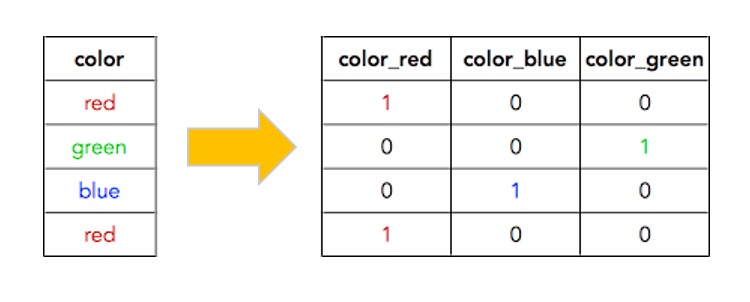

>Этот способ кодирования понятен, хорошо работает как на номинальных, так и на порядковых признаках. Однако существует один минус: количество созданных признаков равно количеству уникальных значений категориального признака. 

Вернёмся к датасету clothing. Закодируем признак type однократным кодированием. Результат кодирования будет выглядеть так: 

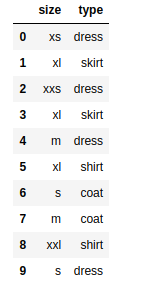
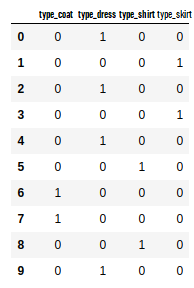

Закодируем признак type в Python. Используем класс [OneHotEncoding](https://contrib.scikit-learn.org/category_encoders/onehot.html) библиотеки *category_encoders*. Укажем в *cols* наименование признака type для кодировки, иначе будут закодированы все строковые столбцы.

In [118]:
import category_encoders as ce # импорт для работы с кодировщиком

encoder = ce.OneHotEncoder(cols=['type'], use_cat_names=True) # указываем столбец для кодирования
type_bin = encoder.fit_transform(clothing['type'])
clothing2 = pd.concat([clothing, type_bin], axis=1)

clothing2

,size,type,type_dress,type_skirt,type_shirt,type_coat
0,xxs,dress,1,0,0,0
1,xxs,skirt,0,1,0,0
2,xs,dress,1,0,0,0
3,s,skirt,0,1,0,0
4,m,dress,1,0,0,0
5,l,shirt,0,0,1,0
6,s,coat,0,0,0,1
7,m,coat,0,0,0,1
8,xxl,shirt,0,0,1,0
9,l,dress,1,0,0,0


Таким образом, мы получили четыре новых признака для категорий coat, dress, shirt, skirt. В строке нужного типа исходного признака стоит значение 1, в остальных строках — 0. Эти признаки пригодны для обучения.

На самом деле метод однократного кодирования реализован в pandas в функции [pd.get_dummies()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html). Для выполнения кодирования достаточно передать в функцию DataFrame и указать столбцы, для которых должно выполняться кодирование. По умолчанию кодирование выполняется для всех столбцов типа object:

In [119]:
clothing_dummies = pd.get_dummies(clothing, columns=['type'])
clothing_dummies

,size,type_coat,type_dress,type_shirt,type_skirt
0,xxs,False,True,False,False
1,xxs,False,False,False,True
2,xs,False,True,False,False
3,s,False,False,False,True
4,m,False,True,False,False
5,l,False,False,True,False
6,s,True,False,False,False
7,m,True,False,False,False
8,xxl,False,False,True,False
9,l,False,True,False,False


Новые бинарные признаки также часто называются **dummy-признаками** или **dummy-переменными**.

---

>В нашем наборе данных винных обзоров признак, обозначающий имя сомелье (taster_name), является номинальным. Закодируйте его, используя One-Hot Encoding.

В ответе напишите, сколько признаков добавилось после применения кодирования.

In [111]:
data_dummies = pd.get_dummies(data, columns=['taster_name'])
data_dummies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129972 entries, 0 to 129971
Data columns (total 42 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Unnamed: 0                      129972 non-null  int64  
 1   country                         129909 non-null  object 
 2   description                     129972 non-null  object 
 3   designation                     129972 non-null  object 
 4   points                          129972 non-null  int64  
 5   province                        129909 non-null  object 
 6   region_1                        129972 non-null  object 
 7   taster_twitter_handle           129972 non-null  object 
 8   title                           129972 non-null  object 
 9   variety                         129971 non-null  object 
 10  winery                          129972 non-null  object 
 11  price_round                     129972 non-null  int64  
 12  year_from_title 

In [112]:
data_dummies.shape[1]

42

In [114]:
encoder = ce.OneHotEncoder(cols=['taster_name'])
type_bin = encoder.fit_transform(data['taster_name'])
data1 = pd.concat([data, type_bin], axis=1)

data1.shape[1]-data.shape[1]

20

---

# <center> Двоичное кодирование

Принцип двоичного кодирования похож на однократное кодирование, но создаёт меньше столбцов. При однократном кодировании признака с количеством уникальных категорий 100 шт. мы создадим 100 новых признаков, а при двоичном кодирования мы сгенерируем всего 7 признаков.

На рисунке ниже представлен алгоритм бинарного кодирования температуры воздуха.


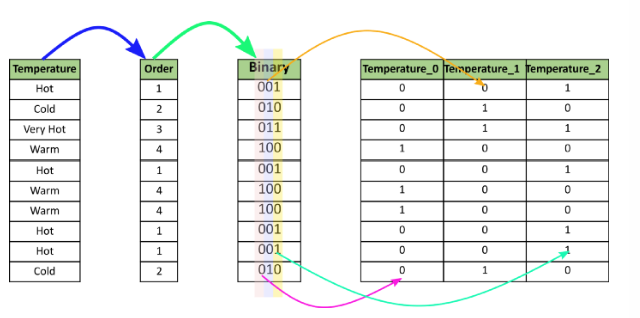

1. Сначала признак кодируется в числовое представление, как мы делали это при кодировании порядковых признаков: hot — 1, cold — 2, … и так далее.
2. Затем каждое числовое представление, выраженное целым числом, переводится в двоичный код: 1 – 001, 2 – 010, 3 – 011,... и так далее.
3. Затем для каждого двоичного представления создаются новые признаки. В нашем случае двоичное представления уместилось в три числа, поэтому итогом стало создание трёх новых признаков.

>Пошаговый алгоритм двоичного кодирования можно описать так: 
* значения признака кодируются в некоторый числовой порядок;
* целые числа кодируются в двоичный код;
* цифры двоичного представления формируют новые столбцы.

Вернёмся к примеру с магазином одежды. Закодируем бинарным способом признак type в Python. Используем класс [BinaryEncoder](https://contrib.scikit-learn.org/category_encoders/binary.html) библиотеки category_encoders.

In [120]:
import category_encoders as ce # импорт для работы с кодировщиком
bin_encoder = ce.BinaryEncoder(cols=['type']) # указываем столбец для кодирования
type_bin = bin_encoder.fit_transform(clothing['type'])
clothing3 = pd.concat([clothing, type_bin], axis=1)

clothing3

,size,type,type_0,type_1,type_2
0,xxs,dress,0,0,1
1,xxs,skirt,0,1,0
2,xs,dress,0,0,1
3,s,skirt,0,1,0
4,m,dress,0,0,1
5,l,shirt,0,1,1
6,s,coat,1,0,0
7,m,coat,1,0,0
8,xxl,shirt,0,1,1
9,l,dress,0,0,1


---

>Закодируйте признак country двоичным способом.

Сколько новых признаков образовалось после кодирования признака country?

In [122]:
import pandas as pd
data = pd.read_csv('data/data.csv',sep= ';')
data.shape[1]

22

In [123]:
bin_encoder = ce.BinaryEncoder(cols=['country']) # указываем столбец для кодирования
type_bin = bin_encoder.fit_transform(data['country'])
data1 = pd.concat([data, type_bin], axis=1)

In [126]:
data1.shape[1]-data.shape[1]

6

>Метод однократного кодирования можно использовать почти во всех сценариях подготовки данных к обучению за исключением некоторых алгоритмов и проблем с памятью. О том, почему из-за этого может возникнуть проблема, вы узнаете подробнее в модулях про машинное обучение. 

В случаях проблем с памятью необходимо обратиться к другим кодировщикам — к порядковому, бинарному кодировщику или иным.

Методы, рассмотренные в модуле, популярны и очень часто используются в кодировании данных за счёт своей простоты, понятности и лёгкости в реализации. Про другие, менее популярные способы кодирования вы можете прочитать в документации к используемой нами библиотеке [category_encoders](https://contrib.scikit-learn.org/category_encoders/).

Выбор подходящего метода кодирования может быть непростой задачей при проектировании признаков. Поэтому всегда необходимо тестировать несколько способов кодирования и выбирать тот, с помощью которого получается качественная предсказательная модель. О том, как измерить качество модели, вы узнаете далее в курсе в модулях про машинное обучение.

>На основе изученного материала определите подходящий способ кодирования признака taster_twitter_handle из датасета винных обзоров и закодируйте его.

В ответе напишите, сколько признаков добавилось после применения кодирования.

In [129]:
data['taster_twitter_handle'].value_counts().count() # уникальных категорий в признаке taster_twitter_handle. 

16

Признак является номинальным. Количество категорий больше 15. Выбираю метод бинарного кодирования

In [131]:
bin_encoder = ce.BinaryEncoder(cols=['taster_twitter_handle']) # указываем столбец для кодирования
type_bin = bin_encoder.fit_transform(data['taster_twitter_handle'])
data2= pd.concat([data, type_bin], axis=1)

In [132]:
print(f"После кодирования признака 'taster_twitter_handle' бинарным методом добавилось {data2.shape[1] - data.shape[1]} признаков")

После кодирования признака 'taster_twitter_handle' бинарным методом добавилось 5 признаков


---

>Определите типы признаков и закодируйте их в соответствии с изученными способами.

In [134]:
list_of_dicts = [
 {'product': 'Product1', 'price': 1200, 'payment_type': 'Mastercard'},
 {'product': 'Product2', 'price': 3600, 'payment_type': 'Visa'},
 {'product': 'Product3', 'price': 7500, 'payment_type': 'Amex'}
]
df = pd.DataFrame(list_of_dicts)
display(df)

,product,price,payment_type
0,Product1,1200,Mastercard
1,Product2,3600,Visa
2,Product3,7500,Amex


In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product       3 non-null      object
 1   price         3 non-null      int64 
 2   payment_type  3 non-null      object
dtypes: int64(1), object(2)
memory usage: 200.0+ bytes


В таблице 2 признака номинального типа. Количество категорий < 15. Выбираю метод однократного кодирования

In [136]:
encoder = ce.OneHotEncoder(cols=['product'])
type_bin = encoder.fit_transform(df['product'])
df = pd.concat([df, type_bin], axis=1)
df

,product,price,payment_type,product_1,product_2,product_3
0,Product1,1200,Mastercard,1,0,0
1,Product2,3600,Visa,0,1,0
2,Product3,7500,Amex,0,0,1


In [137]:
encoder = ce.OneHotEncoder(cols=['payment_type'])
type_bin = encoder.fit_transform(df['payment_type'])
df = pd.concat([df, type_bin], axis=1)
df

,product,price,payment_type,product_1,product_2,product_3,payment_type_1,payment_type_2,payment_type_3
0,Product1,1200,Mastercard,1,0,0,1,0,0
1,Product2,3600,Visa,0,1,0,0,1,0
2,Product3,7500,Amex,0,0,1,0,0,1
